# 08 ตัวอย่างแนวคิด SACIT: ชุมชนหัตถกรรมตามภูมิภาค

Notebook นี้เป็นตัวอย่างเสริมสำหรับการทำ community หรือ regional visualization ใช้ไฟล์ raw ของ SACIT ที่ดาวน์โหลดไว้จริง และไม่เปลี่ยนผลวิเคราะห์ LABAI หลัก

งานนี้ทำเพียง schema review, การตัดช่องว่างของภูมิภาค และกราฟนับจำนวนรายการตามภูมิภาค ไม่สร้าง model หรือแผนที่

## 00 แหล่งข้อมูลและขอบเขต

ใช้ชุดข้อมูลรายการชุมชนหัตถกรรมจากสถาบันส่งเสริมศิลปหัตถกรรมไทย (องค์การมหาชน)

- Metadata: https://data.go.th/dataset/sacit_commu_10
- Resource ที่บันทึกในโครงการ: https://catalog.sacit.or.th/dataset/f825691e-c591-4b3d-b2e1-5794c91bd8ec/resource/89d6f29a-6300-466e-8d55-e6763155286a/download/-2564-2568.xlsx
- ไฟล์ local: `data/raw/sacit_craft_community_2564_2568.xlsx`

ผลเป็นการนับรายการที่มีในไฟล์ ไม่ใช่จำนวนชุมชนหัตถกรรมทั้งหมดของประเทศไทยหรือการประเมินศักยภาพของพื้นที่

## 01 นำเข้าไลบรารี

ใช้ pandas สำหรับข้อมูลจริง, Matplotlib สำหรับกราฟตัวอย่าง และ Path สำหรับระบุตำแหน่งไฟล์

In [1]:
from pathlib import Path
import os

## 02 ค้นหา root ของโครงการ

ตรวจหา `data/raw/` เพื่อให้ notebook ใช้ได้เมื่อเปิดจาก root หรือจากโฟลเดอร์ notebook

In [2]:
def find_project_root():
    current_path = Path.cwd().resolve()
    candidate_paths = [current_path]
    candidate_paths.extend(current_path.parents)

    for candidate_path in candidate_paths:
        if (candidate_path / "data" / "raw").exists():
            return candidate_path

    raise FileNotFoundError("ไม่พบ root ของโครงการที่มี data/raw")


PROJECT_ROOT = find_project_root()


## 03 ตั้งค่า runtime สำหรับกราฟ

กำหนด cache และ backend แบบ non-interactive ใน workspace ก่อน import Matplotlib เพื่อให้รันได้ใน environment ที่ไม่มี GUI

In [3]:
MPL_CONFIG_DIR = PROJECT_ROOT / "figures" / ".matplotlib_cache"
MPL_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CONFIG_DIR))
os.environ.setdefault("MPLBACKEND", "Agg")

'module://matplotlib_inline.backend_inline'

## 04 นำเข้าไลบรารีสำหรับข้อมูลและกราฟ

import Matplotlib หลังตั้งค่า runtime แล้ว และใช้ pandas สำหรับอ่านข้อมูลจริง

In [4]:
from IPython.display import Image, display
import matplotlib as mpl
mpl.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd

## 05 ตั้งค่า font สำหรับกราฟภาษาไทย

ใช้ Sarabun ที่มีอยู่ในโครงการเป็นตัวเลือกแรก และใช้ system font เมื่อไม่พบไฟล์ เพื่อให้ notebook ยังรันได้

In [5]:
FONT_FILE = PROJECT_ROOT / "Sarabun-Regular.ttf"

if FONT_FILE.exists():
    mpl.font_manager.fontManager.addfont(str(FONT_FILE))
    plt.rcParams["font.family"] = "Sarabun"
else:
    plt.rcParams["font.family"] = "sans-serif"

plt.rcParams["axes.unicode_minus"] = False

## 06 กำหนดตำแหน่ง input และ output

ไฟล์ input เป็น XLSX ที่อยู่ใน `data/raw/` และกราฟตัวอย่างจะถูกบันทึกแยกไว้ใน `figures/examples/` เมื่อรัน notebook


In [6]:
RAW_FILE = PROJECT_ROOT / "data" / "raw" / "sacit_craft_community_2564_2568.xlsx"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "examples"
FIGURE_FILE = FIGURE_DIR / "sacit_community_count_by_region.png"

## 07 ตรวจไฟล์ต้นทาง

ไม่สร้างข้อมูลทดแทนเมื่อไม่พบไฟล์จริง เพื่อให้ข้อสรุปของตัวอย่างผูกกับ resource ที่ตรวจสอบได้

In [7]:
if not RAW_FILE.exists():
    raise FileNotFoundError(f"ไม่พบไฟล์ SACIT: {RAW_FILE}")

community_file_status = pd.DataFrame(
    {
        "รายการ": ["ไฟล์ raw", "ที่อยู่ local"],
        "ค่า": [RAW_FILE.name, str(RAW_FILE.relative_to(PROJECT_ROOT))],
    }
)
community_file_status

,รายการ,ค่า
0,ไฟล์ raw,sacit_craft_community_2564_2568.xlsx
1,ที่อยู่ local,data\raw\sacit_craft_community_2564_2568.xlsx


## 08 โหลดข้อมูล raw

อ่าน worksheet เริ่มต้นของ XLSX ตามที่ใช้ใน schema audit และยังไม่เปลี่ยนชื่อ column ต้นฉบับ

In [8]:
sacit_community_raw_df = pd.read_excel(RAW_FILE)
sacit_community_raw_df.head()

,ลำดับ,ปี,ภูมิภาค,จังหวัด,อำเภอ,ชื่อชุมชนหัตถกรรม
0,1,2557,กลาง,พระนครศรีอยุธยา,นครหลวง,ชุมชนหัตถกรรมอรัญญิก
1,2,2558,เหนือ,เชียงใหม่,ดอยเต่า,ชุมชนทอผ้ากะเหรี่ยงบ้านหล่ายแก้ว
2,3,2558,ตะวันออกเฉียงเหนือ,หนองคาย,เมือง,หมู่บ้านจักสานไม้ไผ่บ้านดอนกอก
3,4,2558,เหนือ,เชียงใหม่,เมือง (เชียงใหม่),ชุมชนเครื่องเงิน-เครื่องเขิน วัวลาย
4,5,2559,กลาง,อุทัยธานี,บ้านไร่,ชุมชนหัตถกรรมทอผ้าฝ้ายลาวครั่ง บ้านนาตาโพ


## 09 ตรวจ schema และค่าที่ขาด

ตารางแสดง column ที่ตรวจพบจริง, data type และ missing count ก่อนสร้าง field ช่วยสำหรับกราฟ

In [9]:
community_schema_review_df = pd.DataFrame(
    {
        "column": sacit_community_raw_df.columns,
        "data_type": [str(data_type) for data_type in sacit_community_raw_df.dtypes],
        "missing_count": [int(sacit_community_raw_df[column].isna().sum()) for column in sacit_community_raw_df.columns],
    }
)
community_schema_review_df

,column,data_type,missing_count
0,ลำดับ,int64,0
1,ปี,int64,0
2,ภูมิภาค,object,0
3,จังหวัด,object,0
4,อำเภอ,object,1
5,ชื่อชุมชนหัตถกรรม,object,0


## 10 ตรวจ column ที่ใช้สร้างกราฟ

ตรวจ `ภูมิภาค`, `จังหวัด`, `ปี` และ `ชื่อชุมชนหัตถกรรม` ที่พบจาก schema audit ก่อนใช้สร้าง summary

In [10]:
required_community_columns = ["ภูมิภาค", "จังหวัด", "ปี", "ชื่อชุมชนหัตถกรรม"]
missing_community_columns = [
    column
    for column in required_community_columns
    if column not in sacit_community_raw_df.columns
]

if missing_community_columns:
    raise KeyError(f"ไม่พบ column ที่ต้องใช้ในไฟล์: {missing_community_columns}")

community_column_status_df = pd.DataFrame(
    {
        "column": required_community_columns,
        "exists": [column in sacit_community_raw_df.columns for column in required_community_columns],
    }
)
community_column_status_df

,column,exists
0,ภูมิภาค,True
1,จังหวัด,True
2,ปี,True
3,ชื่อชุมชนหัตถกรรม,True


## 11 ทำความสะอาดข้อความภูมิภาคสำหรับการนับ

สร้าง `ภูมิภาค_clean` โดยตัดช่องว่างต้นและท้ายเท่านั้น และเก็บ column `ภูมิภาค` ต้นฉบับไว้

In [11]:
sacit_community_clean_df = sacit_community_raw_df.copy()
sacit_community_clean_df["ภูมิภาค_clean"] = (
    sacit_community_clean_df["ภูมิภาค"].astype("string").str.strip()
)
sacit_community_clean_df[["ภูมิภาค", "ภูมิภาค_clean", "จังหวัด", "ปี"]].head()

,ภูมิภาค,ภูมิภาค_clean,จังหวัด,ปี
0,กลาง,กลาง,พระนครศรีอยุธยา,2557
1,เหนือ,เหนือ,เชียงใหม่,2558
2,ตะวันออกเฉียงเหนือ,ตะวันออกเฉียงเหนือ,หนองคาย,2558
3,เหนือ,เหนือ,เชียงใหม่,2558
4,กลาง,กลาง,อุทัยธานี,2559


## 12 สรุปจำนวนรายการตามภูมิภาค

ใช้การนับแถวหลังตัดช่องว่างของชื่อภูมิภาค เพื่อดูการกระจายของรายการในไฟล์ ไม่ใช่จำนวนชุมชนทั้งหมดในแต่ละภูมิภาค

In [12]:
region_count_df = (
    sacit_community_clean_df.groupby("ภูมิภาค_clean", dropna=False)
    .size()
    .reset_index(name="จำนวนรายการในไฟล์")
    .sort_values("จำนวนรายการในไฟล์", ascending=False)
)
region_count_df

,ภูมิภาค_clean,จำนวนรายการในไฟล์
0,กลาง,17
2,ตะวันออกเฉียงเหนือ,12
3,เหนือ,12
4,ใต้,8
1,ตะวันออก,2


## 13 สรุปจำนวนรายการตามปีที่มีอยู่

ตารางนี้ตรวจค่าปีที่บันทึกในไฟล์ เพื่อบอกขอบเขตของข้อมูลสำหรับแนวคิด trend หรือ map ในอนาคต

In [13]:
community_year_count_df = (
    sacit_community_clean_df.groupby("ปี", dropna=False)
    .size()
    .reset_index(name="จำนวนรายการในไฟล์")
    .sort_values("ปี")
)
community_year_count_df

,ปี,จำนวนรายการในไฟล์
0,2557,1
1,2558,3
2,2559,6
3,2560,5
4,2561,10
5,2562,13
6,2564,5
7,2565,2
8,2566,2
9,2567,2


## 14 สร้างกราฟจำนวนรายการตามภูมิภาค

กราฟนี้ตอบคำถามว่ารายการชุมชนหัตถกรรมในไฟล์กระจายตามภูมิภาคที่บันทึกไว้อย่างไร และไม่ใช้เป็นแผนที่หรือคะแนนพื้นที่

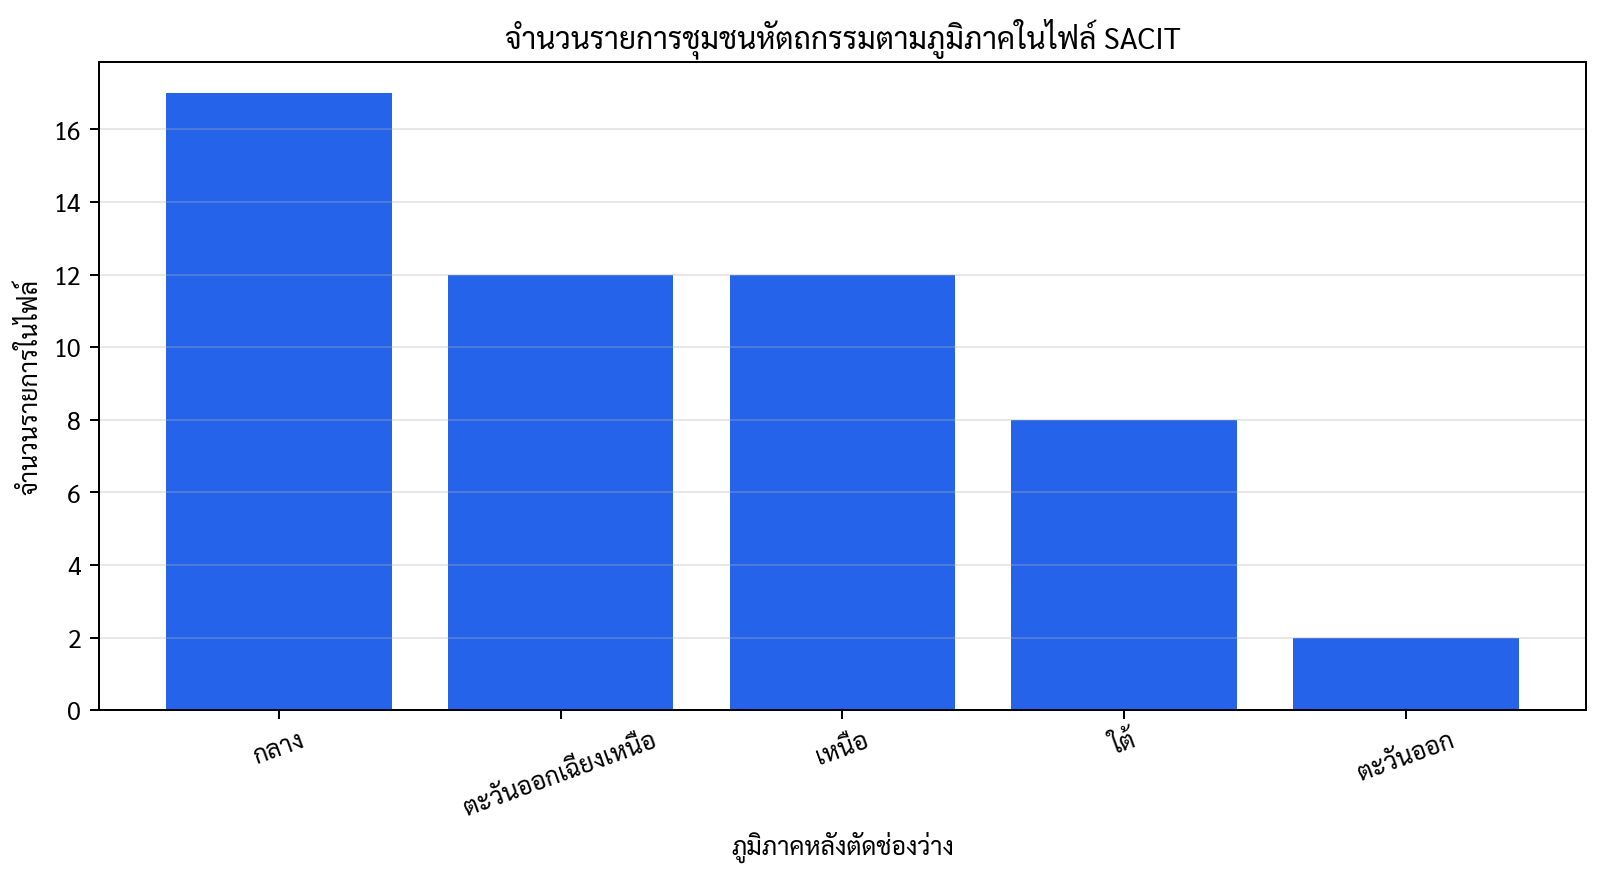

In [14]:
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

figure, axis = plt.subplots(figsize=(9, 5))
axis.bar(
    region_count_df["ภูมิภาค_clean"].astype(str),
    region_count_df["จำนวนรายการในไฟล์"],
    color="#2563eb",
)
axis.set_title("จำนวนรายการชุมชนหัตถกรรมตามภูมิภาคในไฟล์ SACIT")
axis.set_xlabel("ภูมิภาคหลังตัดช่องว่าง")
axis.set_ylabel("จำนวนรายการในไฟล์")
axis.tick_params(axis="x", rotation=20)
axis.grid(axis="y", alpha=0.3)
figure.tight_layout()
figure.savefig(FIGURE_FILE, dpi=180, bbox_inches="tight")
display(Image(filename=str(FIGURE_FILE)))
plt.close(figure)


## 15 ข้อจำกัดและการต่อยอด

ไฟล์นี้ไม่มีพิกัดภูมิศาสตร์ใน column ที่ตรวจพบ จึงยังไม่สร้างแผนที่ การทำ map ในอนาคตต้องยืนยัน key สำหรับเชื่อมพื้นที่, ความสอดคล้องของชื่อจังหวัด และเงื่อนไขการใช้ข้อมูล

การนับรายการตามภูมิภาคไม่ใช่การจัดอันดับศักยภาพของชุมชน และ notebook นี้ไม่สร้าง classification หรือ clustering

## 16 แหล่งข้อมูล

- Metadata: https://data.go.th/dataset/sacit_commu_10
- Resource URL: https://catalog.sacit.or.th/dataset/f825691e-c591-4b3d-b2e1-5794c91bd8ec/resource/89d6f29a-6300-466e-8d55-e6763155286a/download/-2564-2568.xlsx